In [1]:
# ============================================================
# CELL 1 — Run this FIRST, then run the eval cell
# Fixes: PackageNotFoundError: bitsandbytes
# ============================================================

import subprocess, sys

# Force-reinstall bitsandbytes so metadata is present in this kernel session
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "bitsandbytes"], check=True)

import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig

model_id  = "llava-hf/llava-1.5-7b-hf"

bnb_config = BitsAndBytesConfig(load_in_4bit=True)

print("⏳ Loading LLaVA 1.5-7B in 4-bit...")
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    dtype=torch.float16,
    low_cpu_mem_usage=True,
)

processor = AutoProcessor.from_pretrained(model_id)

print("✅ model and processor ready — now run the eval cell below.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 23.4 MB/s eta 0:00:00
⏳ Loading LLaVA 1.5-7B in 4-bit...


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

✅ model and processor ready — now run the eval cell below.


✅ model & processor already in memory.

Running multiple-choice inference on 30 samples...

─────────────────────────────────────────────────────────────────
[01/30] GT=Mouse_bite         Pred=Mouse_bite         Raw='A'  ✅
[02/30] GT=Missing_hole       Pred=Missing_hole       Raw='E'  ✅
[03/30] GT=Short              Pred=Short              Raw='C'  ✅
[04/30] GT=Spurious_copper    Pred=Mouse_bite         Raw='A'  ❌
[05/30] GT=Spur               Pred=Spur               Raw='D'  ✅
[06/30] GT=Spur               Pred=Spur               Raw='D'  ✅
[07/30] GT=Spur               Pred=Spur               Raw='D'  ✅
[08/30] GT=Missing_hole       Pred=Missing_hole       Raw='E'  ✅
[09/30] GT=Spurious_copper    Pred=Mouse_bite         Raw='A'  ❌
[10/30] GT=Open_circuit       Pred=Open_circuit       Raw='B'  ✅
[11/30] GT=Short              Pred=Short              Raw='C'  ✅
[12/30] GT=Missing_hole       Pred=Missing_hole       Raw='E'  ✅
[13/30] GT=Spurious_copper    Pred=Spurious_copper    Raw='F' 

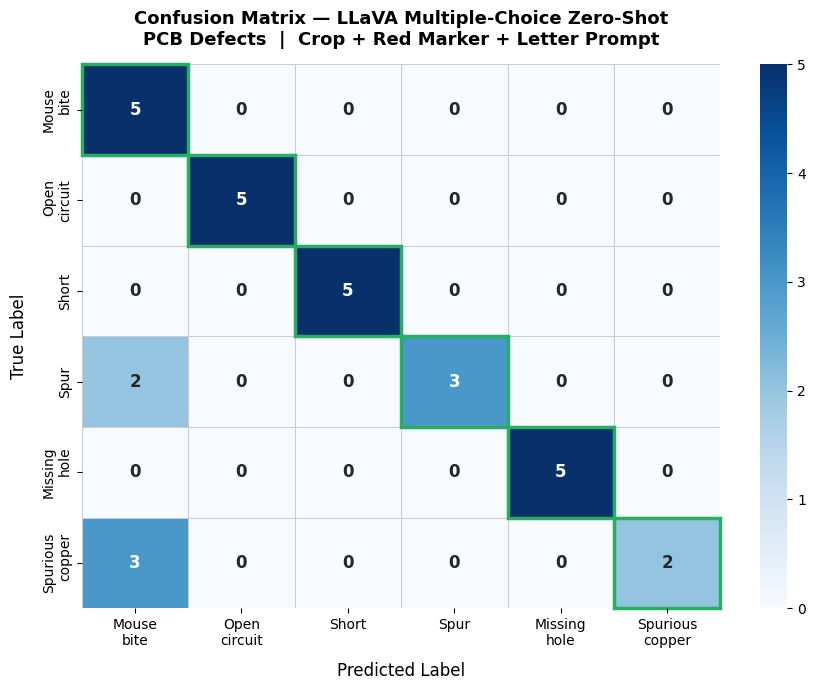

✅ Saved: confusion_matrix_mc.png

Generating prediction grid...


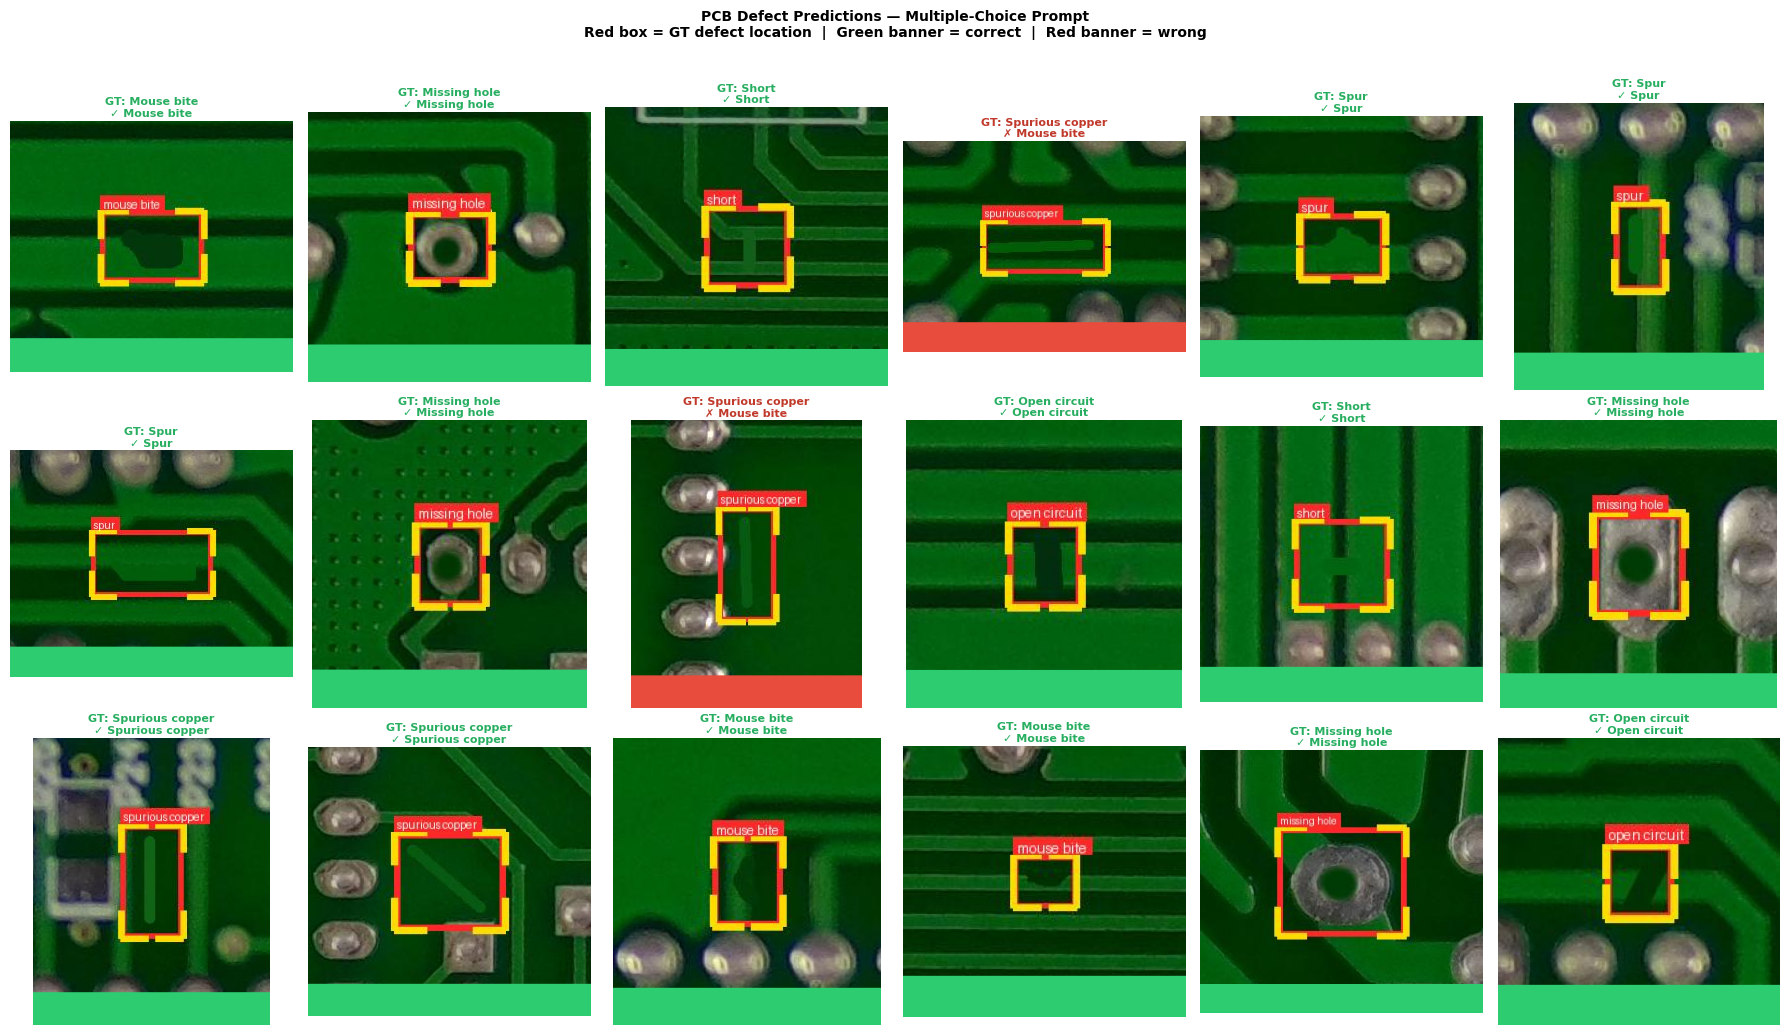

✅ Saved: bbox_grid_mc.png

✅ Done. Check /kaggle/working/ for outputs.


In [2]:
# ============================================================
# FIXED EVALUATION — MULTIPLE-CHOICE PROMPTING
# Stops the "always predict Open_circuit" collapse.
# Replace your previous evaluation cell with this one.
# ============================================================

import os, re, random, torch, xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from sklearn.metrics import confusion_matrix, classification_report, \
    precision_recall_fscore_support, accuracy_score
import seaborn as sns
from PIL import ImageFont

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
BASE_PATH       = "/kaggle/input/datasets/akhatova/pcb-defects/PCB_DATASET/"
IMAGE_ROOT      = os.path.join(BASE_PATH, "images")
ANNOTATION_ROOT = os.path.join(BASE_PATH, "Annotations")

DEFECT_CLASSES  = ["Mouse_bite", "Open_circuit", "Short",
                   "Spur", "Missing_hole", "Spurious_copper"]
SAVE_DIR = "/kaggle/working/annotated_dataset"
os.makedirs(SAVE_DIR, exist_ok=True)

# Multiple-choice letter → class
CHOICE_MAP = {
    "a": "Mouse_bite",
    "b": "Open_circuit",
    "c": "Short",
    "d": "Spur",
    "e": "Missing_hole",
    "f": "Spurious_copper",
}

N_PER_CLASS = 5   # 30 total

# ─────────────────────────────────────────────
# STEP 0 — MODEL GUARD
# ─────────────────────────────────────────────
try:
    model
    processor
    print("✅ model & processor already in memory.")
except NameError:
    from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(load_in_4bit=True)
    model_id   = "llava-hf/llava-1.5-7b-hf"
    model      = LlavaForConditionalGeneration.from_pretrained(
        model_id, dtype=torch.float16,
        low_cpu_mem_usage=True, quantization_config=bnb_config).to(0)
    processor  = AutoProcessor.from_pretrained(model_id)
    print("✅ Model loaded.")

# ─────────────────────────────────────────────
# STEP 1 — XML PARSER
# ─────────────────────────────────────────────
def parse_annotation(cls_name, img_filename):
    xml_path = os.path.join(
        ANNOTATION_ROOT, cls_name,
        os.path.splitext(img_filename)[0] + ".xml"
    )
    if not os.path.exists(xml_path):
        return []
    root  = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall("object"):
        bnd = obj.find("bndbox")
        boxes.append((
            obj.find("name").text,
            int(bnd.find("xmin").text), int(bnd.find("ymin").text),
            int(bnd.find("xmax").text), int(bnd.find("ymax").text),
        ))
    return boxes

# ─────────────────────────────────────────────
# STEP 2 — CROP + DRAW RED MARKER ON DEFECT
# Drawing an arrow/circle directly on the crop
# gives the model a visual pointer so it knows
# exactly WHAT region to classify.
# ─────────────────────────────────────────────
def make_marked_crop(pil_img, boxes, pad=80):
    W, H = pil_img.size

    if boxes:
        label, xmin, ymin, xmax, ymax = boxes[0]   # ✅ FIXED

        cx1 = max(0, xmin - pad)
        cy1 = max(0, ymin - pad)
        cx2 = min(W, xmax + pad)
        cy2 = min(H, ymax + pad)

        crop = pil_img.crop((cx1, cy1, cx2, cy2)).copy()

        bx1, by1 = xmin - cx1, ymin - cy1
        bx2, by2 = xmax - cx1, ymax - cy1

    else:
        crop = pil_img.copy()
        bx1, by1 = 10, 10
        bx2, by2 = crop.width - 10, crop.height - 10
        label = "unknown"

    draw = ImageDraw.Draw(crop)

    lw = max(4, min(crop.width, crop.height) // 40)

    # 🔴 Bounding box
    draw.rectangle([bx1, by1, bx2, by2], outline=(255, 40, 40), width=lw)

    # 🟡 Corner ticks
    tick = lw * 5
    for (sx, ex, sy, ey) in [
        (bx1, bx1+tick, by1, by1), (bx1, bx1, by1, by1+tick),
        (bx2-tick, bx2, by2, by2), (bx2, bx2, by2-tick, by2),
        (bx1, bx1+tick, by2, by2), (bx1, bx1, by2-tick, by2),
        (bx2-tick, bx2, by1, by1), (bx2, bx2, by1, by1+tick),
    ]:
        draw.line([(sx, sy), (ex, ey)], fill=(255, 220, 0), width=lw+1)

    # 🔥🔥🔥 ADD THIS BLOCK (TEXT ANNOTATION) 🔥🔥🔥
    text = label.replace("_", " ")

    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", size=18)
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    text_x = bx1
    text_y = by1 - text_height - 5

    if text_y < 0:
        text_y = by1 + 5

    draw.rectangle(
        [text_x, text_y, text_x + text_width + 6, text_y + text_height + 4],
        fill=(255, 40, 40)
    )

    draw.text(
        (text_x + 3, text_y + 2),
        text,
        fill="white",
        font=font
    )
    # 🔥🔥🔥 END OF TEXT BLOCK 🔥🔥🔥

    # 💾 Save
    save_name = f"annotated_{random.randint(0, 1_000_000)}.jpg"
    save_path = os.path.join(SAVE_DIR, save_name)
    crop.save(save_path)

    return crop, save_path

# ─────────────────────────────────────────────
# STEP 3 — MULTIPLE-CHOICE INFERENCE
# Asks the model to reply with a SINGLE LETTER.
# Eliminates keyword-parsing entirely.
# ─────────────────────────────────────────────
VISUAL_HINTS = {
    "Mouse_bite":      "a bite-shaped notch missing from a copper edge",
    "Open_circuit":    "a complete gap/break in a copper trace",
    "Short":           "two copper traces accidentally touching or bridged",
    "Spur":            "a thin copper spike sticking out from a trace",
    "Missing_hole":    "a pad or via where the drill hole is absent",
    "Spurious_copper": "an unwanted copper blob or island on the board",
}

PROMPT_TEMPLATE = """You are an expert PCB quality-control inspector.
The text label in the image identifies the exact defect. The red rectangle in the image marks the defect location.

Look MAINLY at the text label and identify the defect.
Analyze the region within the red rectangle for hints ONLY IF the text label is not clear.
Choose the defect:

A) Mouse_bite      — {a}
B) Open_circuit    — {b}
C) Short           — {c}
D) Spur            — {d}
E) Missing_hole    — {e}
F) Spurious_copper — {f}

Reply with ONLY the single capital letter (A, B, C, D, E, or F).
No other words.""".format(
    a=VISUAL_HINTS["Mouse_bite"],
    b=VISUAL_HINTS["Open_circuit"],
    c=VISUAL_HINTS["Short"],
    d=VISUAL_HINTS["Spur"],
    e=VISUAL_HINTS["Missing_hole"],
    f=VISUAL_HINTS["Spurious_copper"],
)

def run_multiple_choice(crop: Image.Image) -> str:
    """
    Returns the predicted class name by extracting a single letter
    from the model's response. Robust to extra words.
    """
    conv = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": PROMPT_TEMPLATE}
    ]}]
    text = processor.apply_chat_template(conv, add_generation_prompt=True)
    inp  = processor(images=crop, text=text, return_tensors="pt").to(model.device, torch.float16)
    out  = model.generate(**inp, max_new_tokens=10, do_sample=False)
    raw  = processor.decode(out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True).strip()

    # Extract first A-F letter anywhere in the response
    match = re.search(r'\b([A-Fa-f])\b', raw)
    if match:
        letter = match.group(1).lower()
        return CHOICE_MAP.get(letter, "Unknown"), raw

    # Fallback: scan for any A-F character
    for ch in raw:
        if ch.lower() in CHOICE_MAP:
            return CHOICE_MAP[ch.lower()], raw

    return "Unknown", raw

# ─────────────────────────────────────────────
# STEP 4 — SAMPLE BUILDER
# ─────────────────────────────────────────────
def build_samples(n_per_class):
    samples = []
    for cls in DEFECT_CLASSES:
        cls_path = os.path.join(IMAGE_ROOT, cls)
        files    = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".png",".jpeg"))]
        for fname in random.sample(files, min(n_per_class, len(files))):
            img   = Image.open(os.path.join(cls_path, fname)).convert("RGB")
            boxes = parse_annotation(cls, fname)
            samples.append({"img": img, "fname": fname, "gt": cls, "boxes": boxes})
    random.shuffle(samples)
    return samples

# ─────────────────────────────────────────────
# STEP 5 — EVALUATION LOOP
# ─────────────────────────────────────────────
random.seed(42)
samples = build_samples(N_PER_CLASS)
y_true, y_pred = [], []
n = len(samples)

print(f"\nRunning multiple-choice inference on {n} samples...\n")
print(f"{'─'*65}")

for i, s in enumerate(samples):
    crop, save_path = make_marked_crop(s["img"], s["boxes"])

    # 🔥 IMPORTANT: reload from saved image (your new dataset)
    crop = Image.open(save_path).convert("RGB")
    pred, raw    = run_multiple_choice(crop)
    s["pred"]    = pred
    s["crop"]    = crop
    s["annotated_path"] = save_path
    s["raw"]     = raw
    y_true.append(s["gt"])
    y_pred.append(pred)
    ok = "✅" if pred == s["gt"] else "❌"
    print(f"[{i+1:02d}/{n}] GT={s['gt']:<18} Pred={pred:<18} Raw='{raw[:12]}'  {ok}")

# ─────────────────────────────────────────────
# STEP 6 — METRICS
# ─────────────────────────────────────────────
print(f"\n{'═'*65}")
print("  METRICS — Multiple-Choice Zero-Shot")
print(f"{'═'*65}")
acc = accuracy_score(y_true, y_pred)
unk = y_pred.count("Unknown") / len(y_pred)
print(f"  Accuracy     : {acc:.3f}  ({acc*100:.1f}%)")
print(f"  Unknown Rate : {unk:.3f}  ({unk*100:.1f}%)\n")

valid_labels = [l for l in DEFECT_CLASSES if l in y_true or l in y_pred]
print(classification_report(y_true, y_pred, labels=DEFECT_CLASSES,
                             target_names=DEFECT_CLASSES, zero_division=0, digits=3))

for avg in ("macro", "weighted"):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average=avg, labels=DEFECT_CLASSES, zero_division=0)
    print(f"  [{avg.upper():8s}]  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")

# ─────────────────────────────────────────────
# STEP 7 — CONFUSION MATRIX
# ─────────────────────────────────────────────
label_set = DEFECT_CLASSES + (["Unknown"] if "Unknown" in y_pred else [])
cm        = confusion_matrix(y_true, y_pred, labels=label_set)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[c.replace("_", "\n") for c in label_set],
    yticklabels=[c.replace("_", "\n") for c in label_set],
    linewidths=0.5, linecolor="#ccc",
    ax=ax, annot_kws={"size": 12, "weight": "bold"}
)
# Highlight diagonal
for k in range(len(label_set)):
    ax.add_patch(plt.Rectangle((k, k), 1, 1,
                 fill=False, edgecolor="#27ae60", lw=2.5, clip_on=False))

ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
ax.set_ylabel("True Label",      fontsize=12, labelpad=10)
ax.set_title(
    "Confusion Matrix — LLaVA Multiple-Choice Zero-Shot\n"
    "PCB Defects  |  Crop + Red Marker + Letter Prompt",
    fontsize=13, fontweight="bold", pad=14
)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_mc.png", dpi=160, bbox_inches="tight")
plt.show()
print("✅ Saved: confusion_matrix_mc.png")

# ─────────────────────────────────────────────
# STEP 8 — BBOX + PREDICTION OVERLAY GRID
# ─────────────────────────────────────────────
def plot_bbox_grid(samples, max_show=18):
    show = samples[:max_show]
    cols = 6
    rows = (len(show) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.4))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else list(axes)

    for i, s in enumerate(show):
        crop    = s["crop"]
        correct = (s["pred"] == s["gt"])

        # Add prediction banner
        vis   = crop.copy()
        draw  = ImageDraw.Draw(vis)
        bh    = max(30, vis.height // 10)
        color = (46, 204, 113) if correct else (231, 76, 60)
        draw.rectangle([0, vis.height - bh, vis.width, vis.height], fill=color)
        try:
            font = ImageFont.truetype("DejaVuSans-Bold.ttf", size=18)
        except:
            font = ImageFont.load_default()

        axes_flat[i].imshow(vis)
        tc = "#27ae60" if correct else "#c0392b"
        axes_flat[i].set_title(
            f"GT: {s['gt'].replace('_',' ')}\n"
            f"{'✓' if correct else '✗'} {s['pred'].replace('_',' ')}",
            fontsize=8, color=tc, fontweight="bold", pad=3
        )
        axes_flat[i].axis("off")

    for j in range(len(show), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(
        "PCB Defect Predictions — Multiple-Choice Prompt\n"
        "Red box = GT defect location  |  Green banner = correct  |  Red banner = wrong",
        fontsize=10, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.savefig("/kaggle/working/bbox_grid_mc.png", dpi=160, bbox_inches="tight")
    plt.show()
    print("✅ Saved: bbox_grid_mc.png")

print("\nGenerating prediction grid...")
plot_bbox_grid(samples)
print("\n✅ Done. Check /kaggle/working/ for outputs.")


══════════════════════════════════════════════════════════════════════════════════════════
  PCB DEFECT DATASET STATISTICS  (VAL_SPLIT=0.2, SEED=42)
══════════════════════════════════════════════════════════════════════════════════════════
  Class                 Total imgs   Total boxes   Train imgs   Train boxes   Val imgs   Val boxes
──────────────────────────────────────────────────────────────────────────────────────────
  Mouse_bite                   115           492           89           379         26         113
  Open_circuit                 116           482           93           384         23          98
  Short                        116           491           96           405         20          86
  Spur                         115           488           95           402         20          86
  Missing_hole                 115           497           96           408         19          89
  Spurious_copper              116           503           85           37

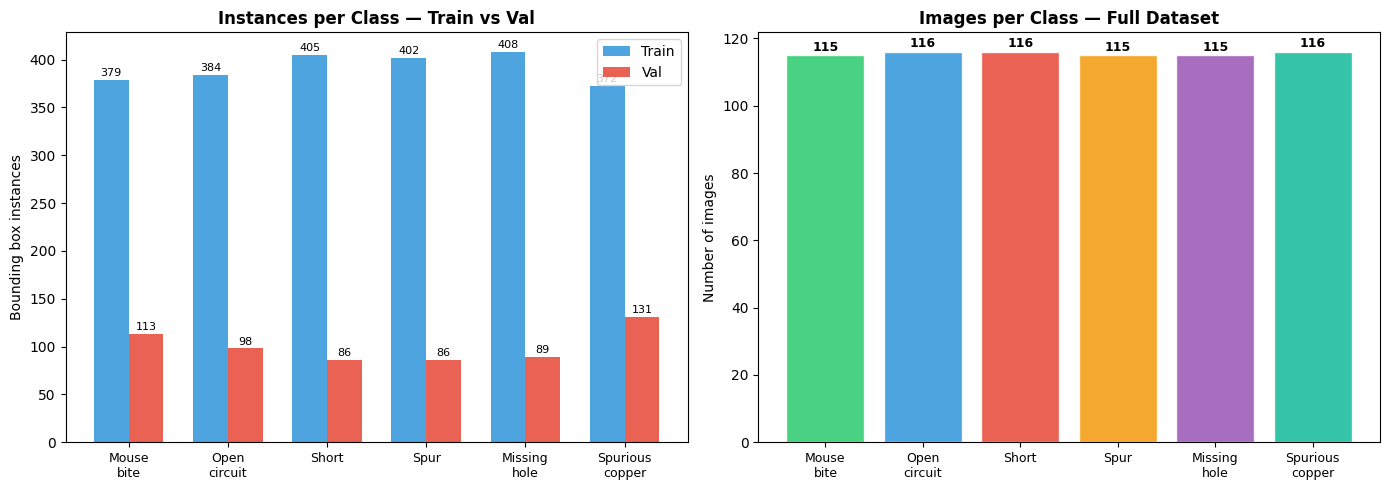

✅ Saved: dataset_statistics.png


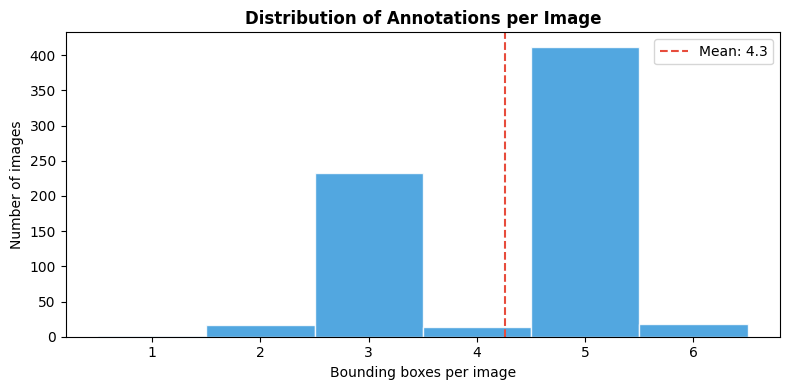

✅ Saved: boxes_per_image_dist.png

  Quick summary:
  Total images      : 693
  Total bbox instances : 2953
  Avg boxes/image   : 4.26
  Max boxes/image   : 6


In [3]:
# ============================================================
# PCB DATASET STATISTICS
# Counts every bounding box instance per class across the
# full dataset, then shows the train/val split breakdown.
# Run this as a standalone cell — no model needed.
# ============================================================

import os, xml.etree.ElementTree as ET, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE_PATH       = "/kaggle/input/datasets/akhatova/pcb-defects/PCB_DATASET/"
ANNOTATION_ROOT = os.path.join(BASE_PATH, "Annotations")
IMAGE_ROOT      = os.path.join(BASE_PATH, "images")

DEFECT_CLASSES  = ["Mouse_bite", "Open_circuit", "Short",
                   "Spur", "Missing_hole", "Spurious_copper"]

VAL_SPLIT = 0.2
SEED      = 42
random.seed(SEED)

# ─────────────────────────────────────────────
# STEP 1 — COUNT EVERYTHING
# ─────────────────────────────────────────────
# Per class: number of images, number of bbox instances
img_counts  = {c: 0 for c in DEFECT_CLASSES}
bbox_counts = {c: 0 for c in DEFECT_CLASSES}
all_records = []   # (class, n_boxes_in_this_image) for split reporting

for cls in DEFECT_CLASSES:
    xml_dir = os.path.join(ANNOTATION_ROOT, cls)
    if not os.path.exists(xml_dir):
        print(f"⚠️  Missing annotation folder: {xml_dir}")
        continue
    xml_files = [f for f in os.listdir(xml_dir) if f.endswith(".xml")]
    for xml_file in xml_files:
        root = ET.parse(os.path.join(xml_dir, xml_file)).getroot()
        objs = root.findall("object")
        n    = len(objs)
        if n == 0:
            continue
        img_counts[cls]  += 1
        bbox_counts[cls] += n
        all_records.append((cls, n))

total_imgs  = sum(img_counts.values())
total_boxes = sum(bbox_counts.values())

# ─────────────────────────────────────────────
# STEP 2 — SIMULATE TRAIN / VAL SPLIT
# Mirrors exactly what the training cell does
# ─────────────────────────────────────────────
random.shuffle(all_records)
split_at   = int(len(all_records) * (1 - VAL_SPLIT))
train_recs = all_records[:split_at]
val_recs   = all_records[split_at:]

train_imgs  = {c: 0 for c in DEFECT_CLASSES}
train_boxes = {c: 0 for c in DEFECT_CLASSES}
val_imgs    = {c: 0 for c in DEFECT_CLASSES}
val_boxes   = {c: 0 for c in DEFECT_CLASSES}

for cls, n in train_recs:
    train_imgs[cls]  += 1
    train_boxes[cls] += n
for cls, n in val_recs:
    val_imgs[cls]  += 1
    val_boxes[cls] += n

# ─────────────────────────────────────────────
# STEP 3 — PRINT TABLE
# ─────────────────────────────────────────────
W = 20
print("\n" + "═"*90)
print(f"  PCB DEFECT DATASET STATISTICS  (VAL_SPLIT={VAL_SPLIT}, SEED={SEED})")
print("═"*90)
print(f"  {'Class':<{W}}  {'Total imgs':>10}  {'Total boxes':>12}  "
      f"{'Train imgs':>11}  {'Train boxes':>12}  "
      f"{'Val imgs':>9}  {'Val boxes':>10}")
print("─"*90)

for cls in DEFECT_CLASSES:
    print(f"  {cls:<{W}}  {img_counts[cls]:>10}  {bbox_counts[cls]:>12}  "
          f"  {train_imgs[cls]:>9}  {train_boxes[cls]:>12}  "
          f"  {val_imgs[cls]:>7}  {val_boxes[cls]:>10}")

print("─"*90)
print(f"  {'TOTAL':<{W}}  {total_imgs:>10}  {total_boxes:>12}  "
      f"  {sum(train_imgs.values()):>9}  {sum(train_boxes.values()):>12}  "
      f"  {sum(val_imgs.values()):>7}  {sum(val_boxes.values()):>10}")
print("═"*90)

# ─────────────────────────────────────────────
# STEP 4 — IMBALANCE CHECK
# ─────────────────────────────────────────────
print("\n  CLASS BALANCE (% of total bounding boxes)")
print("─"*50)
for cls in DEFECT_CLASSES:
    pct = bbox_counts[cls] / total_boxes * 100
    bar = "█" * int(pct / 2)
    print(f"  {cls:<{W}}  {pct:5.1f}%  {bar}")
print()

# ─────────────────────────────────────────────
# STEP 5 — PLOTS
# ─────────────────────────────────────────────
SHORT = [c.replace("_", "\n") for c in DEFECT_CLASSES]
x     = np.arange(len(DEFECT_CLASSES))
w     = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Plot 1: Bounding box instances (train vs val) —
ax = axes[0]
b1 = ax.bar(x - w/2, [train_boxes[c] for c in DEFECT_CLASSES],
            w, label="Train", color="#3498db", alpha=0.88)
b2 = ax.bar(x + w/2, [val_boxes[c]   for c in DEFECT_CLASSES],
            w, label="Val",   color="#e74c3c", alpha=0.88)
ax.set_xticks(x); ax.set_xticklabels(SHORT, fontsize=9)
ax.set_ylabel("Bounding box instances")
ax.set_title("Instances per Class — Train vs Val", fontweight="bold")
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 2,
            str(int(h)), ha="center", va="bottom", fontsize=8)

# — Plot 2: Image count per class (full dataset) —
ax2   = axes[1]
colors = ["#2ecc71","#3498db","#e74c3c","#f39c12","#9b59b6","#1abc9c"]
bars  = ax2.bar(x, [img_counts[c] for c in DEFECT_CLASSES],
                color=colors, alpha=0.88, edgecolor="white")
ax2.set_xticks(x); ax2.set_xticklabels(SHORT, fontsize=9)
ax2.set_ylabel("Number of images")
ax2.set_title("Images per Class — Full Dataset", fontweight="bold")
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.5,
             str(int(h)), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/dataset_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: dataset_statistics.png")

# ─────────────────────────────────────────────
# STEP 6 — BOXES PER IMAGE DISTRIBUTION
# ─────────────────────────────────────────────
boxes_per_img = [n for _, n in all_records]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boxes_per_img, bins=range(1, max(boxes_per_img)+2),
        color="#3498db", edgecolor="white", alpha=0.85, align="left")
ax.set_xlabel("Bounding boxes per image")
ax.set_ylabel("Number of images")
ax.set_title("Distribution of Annotations per Image", fontweight="bold")
ax.axvline(np.mean(boxes_per_img), color="#e74c3c", linestyle="--",
           label=f"Mean: {np.mean(boxes_per_img):.1f}")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/boxes_per_image_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: boxes_per_image_dist.png")

print(f"\n  Quick summary:")
print(f"  Total images      : {total_imgs}")
print(f"  Total bbox instances : {total_boxes}")
print(f"  Avg boxes/image   : {np.mean(boxes_per_img):.2f}")
print(f"  Max boxes/image   : {max(boxes_per_img)}")

In [4]:
PROMPT_TEMPLATE = """You are an expert PCB quality-control inspector.
The red rectangle in the image marks the defect location.

Analyze the region within the red rectangle for hints and identify the defect.
Choose the defect:

A) Mouse_bite      — {a}
B) Open_circuit    — {b}
C) Short           — {c}
D) Spur            — {d}
E) Missing_hole    — {e}
F) Spurious_copper — {f}

Reply with ONLY the single capital letter (A, B, C, D, E, or F).
No other words.""".format(
    a=VISUAL_HINTS["Mouse_bite"],
    b=VISUAL_HINTS["Open_circuit"],
    c=VISUAL_HINTS["Short"],
    d=VISUAL_HINTS["Spur"],
    e=VISUAL_HINTS["Missing_hole"],
    f=VISUAL_HINTS["Spurious_copper"],
)

✅ model & processor already in memory.

Running comparison on 30 samples...

───────────────────────────────────────────────────────────────────────────
[01] GT=Mouse_bite      | Zero=Mouse_bite      | Few=Mouse_bite     
[02] GT=Missing_hole    | Zero=Missing_hole    | Few=Missing_hole   
[03] GT=Short           | Zero=Short           | Few=Short          
[04] GT=Spurious_copper | Zero=Mouse_bite      | Few=Spurious_copper
[05] GT=Spur            | Zero=Spur            | Few=Spur           
[06] GT=Spur            | Zero=Spur            | Few=Spur           
[07] GT=Spur            | Zero=Spur            | Few=Spur           
[08] GT=Missing_hole    | Zero=Missing_hole    | Few=Missing_hole   
[09] GT=Spurious_copper | Zero=Mouse_bite      | Few=Spurious_copper
[10] GT=Open_circuit    | Zero=Open_circuit    | Few=Open_circuit   
[11] GT=Short           | Zero=Short           | Few=Short          
[12] GT=Missing_hole    | Zero=Missing_hole    | Few=Missing_hole   
[13] GT=Spurious_co

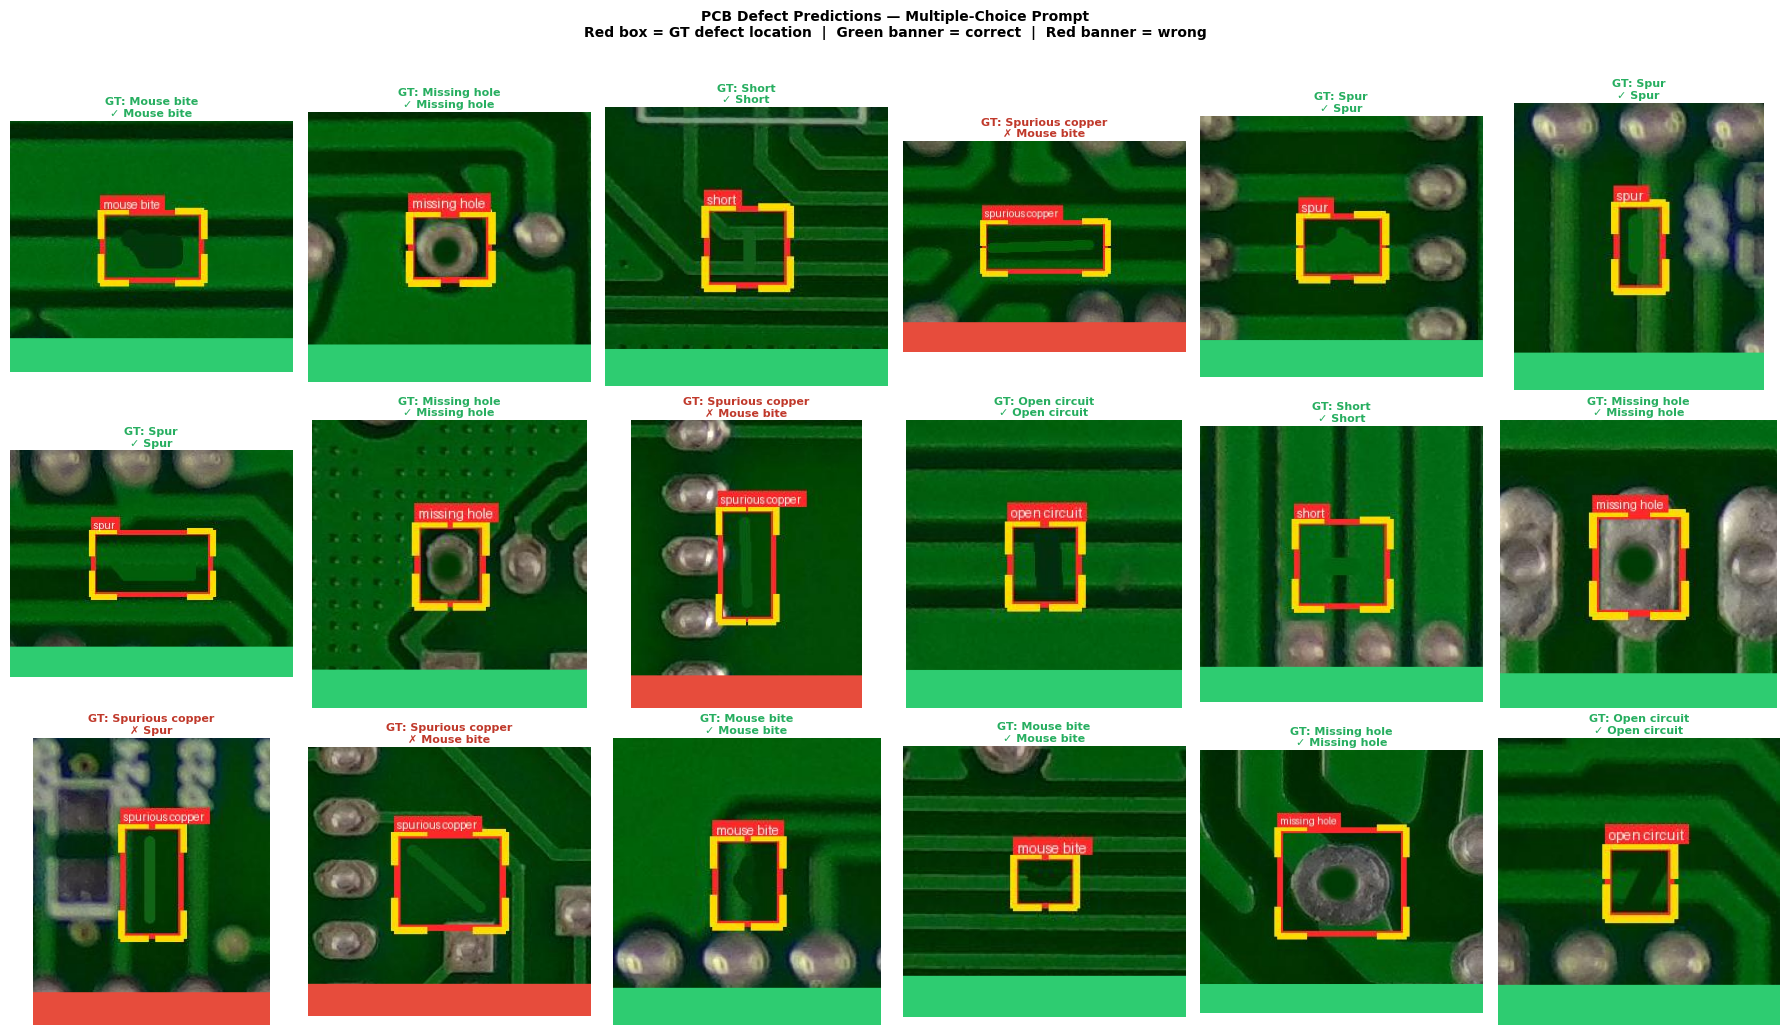

✅ Saved: bbox_grid_mc.png

✅ Done. Check /kaggle/working/ for outputs.


In [5]:
# ============================================================
# FIXED EVALUATION — MULTIPLE-CHOICE PROMPTING
# Stops the "always predict Open_circuit" collapse.
# Replace your previous evaluation cell with this one.
# ============================================================

import os, re, random, torch, xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from sklearn.metrics import confusion_matrix, classification_report, \
    precision_recall_fscore_support, accuracy_score
import seaborn as sns
from PIL import ImageFont

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
BASE_PATH       = "/kaggle/input/datasets/akhatova/pcb-defects/PCB_DATASET/"
IMAGE_ROOT      = os.path.join(BASE_PATH, "images")
ANNOTATION_ROOT = os.path.join(BASE_PATH, "Annotations")

DEFECT_CLASSES  = ["Mouse_bite", "Open_circuit", "Short",
                   "Spur", "Missing_hole", "Spurious_copper"]
SAVE_DIR = "/kaggle/working/annotated_dataset"
os.makedirs(SAVE_DIR, exist_ok=True)

# Multiple-choice letter → class
CHOICE_MAP = {
    "a": "Mouse_bite",
    "b": "Open_circuit",
    "c": "Short",
    "d": "Spur",
    "e": "Missing_hole",
    "f": "Spurious_copper",
}

N_PER_CLASS = 5   # 30 total

# ─────────────────────────────────────────────
# STEP 0 — MODEL GUARD
# ─────────────────────────────────────────────
try:
    model
    processor
    print("✅ model & processor already in memory.")
except NameError:
    from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(load_in_4bit=True)
    model_id   = "llava-hf/llava-1.5-7b-hf"
    model      = LlavaForConditionalGeneration.from_pretrained(
        model_id, dtype=torch.float16,
        low_cpu_mem_usage=True, quantization_config=bnb_config).to(0)
    processor  = AutoProcessor.from_pretrained(model_id)
    print("✅ Model loaded.")

# ─────────────────────────────────────────────
# STEP 1 — XML PARSER
# ─────────────────────────────────────────────
def parse_annotation(cls_name, img_filename):
    xml_path = os.path.join(
        ANNOTATION_ROOT, cls_name,
        os.path.splitext(img_filename)[0] + ".xml"
    )
    if not os.path.exists(xml_path):
        return []
    root  = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall("object"):
        bnd = obj.find("bndbox")
        boxes.append((
            obj.find("name").text,
            int(bnd.find("xmin").text), int(bnd.find("ymin").text),
            int(bnd.find("xmax").text), int(bnd.find("ymax").text),
        ))
    return boxes

# ─────────────────────────────────────────────
# STEP 2 — CROP + DRAW RED MARKER ON DEFECT
# Drawing an arrow/circle directly on the crop
# gives the model a visual pointer so it knows
# exactly WHAT region to classify.
# ─────────────────────────────────────────────
def make_marked_crop(pil_img, boxes, pad=80):
    W, H = pil_img.size

    if boxes:
        label, xmin, ymin, xmax, ymax = boxes[0]   # ✅ FIXED

        cx1 = max(0, xmin - pad)
        cy1 = max(0, ymin - pad)
        cx2 = min(W, xmax + pad)
        cy2 = min(H, ymax + pad)

        crop = pil_img.crop((cx1, cy1, cx2, cy2)).copy()

        bx1, by1 = xmin - cx1, ymin - cy1
        bx2, by2 = xmax - cx1, ymax - cy1

    else:
        crop = pil_img.copy()
        bx1, by1 = 10, 10
        bx2, by2 = crop.width - 10, crop.height - 10
        label = "unknown"

    draw = ImageDraw.Draw(crop)

    lw = max(4, min(crop.width, crop.height) // 40)

    # 🔴 Bounding box
    draw.rectangle([bx1, by1, bx2, by2], outline=(255, 40, 40), width=lw)

    # 🟡 Corner ticks
    tick = lw * 5
    for (sx, ex, sy, ey) in [
        (bx1, bx1+tick, by1, by1), (bx1, bx1, by1, by1+tick),
        (bx2-tick, bx2, by2, by2), (bx2, bx2, by2-tick, by2),
        (bx1, bx1+tick, by2, by2), (bx1, bx1, by2-tick, by2),
        (bx2-tick, bx2, by1, by1), (bx2, bx2, by1, by1+tick),
    ]:
        draw.line([(sx, sy), (ex, ey)], fill=(255, 220, 0), width=lw+1)

    # 🔥🔥🔥 ADD THIS BLOCK (TEXT ANNOTATION) 🔥🔥🔥
    text = label.replace("_", " ")

    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", size=18)
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    text_x = bx1
    text_y = by1 - text_height - 5

    if text_y < 0:
        text_y = by1 + 5

    draw.rectangle(
        [text_x, text_y, text_x + text_width + 6, text_y + text_height + 4],
        fill=(255, 40, 40)
    )

    draw.text(
        (text_x + 3, text_y + 2),
        text,
        fill="white",
        font=font
    )
    # 🔥🔥🔥 END OF TEXT BLOCK 🔥🔥🔥

    # 💾 Save
    save_name = f"annotated_{random.randint(0, 1_000_000)}.jpg"
    save_path = os.path.join(SAVE_DIR, save_name)
    crop.save(save_path)

    return crop, save_path

# ─────────────────────────────────────────────
# STEP 3 — MULTIPLE-CHOICE INFERENCE
# Asks the model to reply with a SINGLE LETTER.
# Eliminates keyword-parsing entirely.
# ─────────────────────────────────────────────
VISUAL_HINTS = {
    "Mouse_bite":      "a bite-shaped notch missing from a copper edge",
    "Open_circuit":    "a complete gap/break in a copper trace",
    "Short":           "two copper traces accidentally touching or bridged",
    "Spur":            "a thin copper spike sticking out from a trace",
    "Missing_hole":    "a pad or via where the drill hole is absent",
    "Spurious_copper": "an unwanted copper blob or island on the board",
}

# ─────────────────────────────────────────────
# STEP 3 — ZERO SHOT + FEW SHOT INFERENCE
# ─────────────────────────────────────────────

PROMPT_TEMPLATE_FEW_SHOT = """You are an expert PCB quality-control inspector.

Each image contains:
- A red rectangle marking the defect location
- A text label that may indicate the defect

Examples:

Example 1:
Label: open circuit → Answer: B

Example 2:
Label: short → Answer: C

Example 3:
Label: missing hole → Answer: E

Now analyze the given image.

Focus primarily on the text label. If unclear, use the visual region.

Choose the defect:

A) Mouse_bite
B) Open_circuit
C) Short
D) Spur
E) Missing_hole
F) Spurious_copper

Reply with ONLY one letter (A–F).
"""

def run_few_shot(crop: Image.Image):
    conv = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": PROMPT_TEMPLATE_FEW_SHOT}
    ]}]
    
    text = processor.apply_chat_template(conv, add_generation_prompt=True)
    
    inp = processor(images=crop, text=text, return_tensors="pt").to(model.device, torch.float16)
    
    out = model.generate(**inp, max_new_tokens=10, do_sample=False)
    
    raw = processor.decode(out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True).strip()

    match = re.search(r'\b([A-Fa-f])\b', raw)
    if match:
        return CHOICE_MAP.get(match.group(1).lower(), "Unknown"), raw

    for ch in raw:
        if ch.lower() in CHOICE_MAP:
            return CHOICE_MAP[ch.lower()], raw

    return "Unknown", raw

def run_multiple_choice(crop: Image.Image) -> str:
    """
    Returns the predicted class name by extracting a single letter
    from the model's response. Robust to extra words.
    """
    conv = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": PROMPT_TEMPLATE}
    ]}]
    text = processor.apply_chat_template(conv, add_generation_prompt=True)
    inp  = processor(images=crop, text=text, return_tensors="pt").to(model.device, torch.float16)
    out  = model.generate(**inp, max_new_tokens=10, do_sample=False)
    raw  = processor.decode(out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True).strip()

    # Extract first A-F letter anywhere in the response
    match = re.search(r'\b([A-Fa-f])\b', raw)
    if match:
        letter = match.group(1).lower()
        return CHOICE_MAP.get(letter, "Unknown"), raw

    # Fallback: scan for any A-F character
    for ch in raw:
        if ch.lower() in CHOICE_MAP:
            return CHOICE_MAP[ch.lower()], raw

    return "Unknown", raw

# ─────────────────────────────────────────────
# STEP 4 — SAMPLE BUILDER
# ─────────────────────────────────────────────
def build_samples(n_per_class):
    samples = []
    for cls in DEFECT_CLASSES:
        cls_path = os.path.join(IMAGE_ROOT, cls)
        files    = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".png",".jpeg"))]
        for fname in random.sample(files, min(n_per_class, len(files))):
            img   = Image.open(os.path.join(cls_path, fname)).convert("RGB")
            boxes = parse_annotation(cls, fname)
            samples.append({"img": img, "fname": fname, "gt": cls, "boxes": boxes})
    random.shuffle(samples)
    return samples

# ─────────────────────────────────────────────
# STEP 5 — EVALUATION LOOP
# ─────────────────────────────────────────────
# ─────────────────────────────────────────────
# STEP 5 — EVALUATION LOOP (ZERO vs FEW)
# ─────────────────────────────────────────────

random.seed(42)
samples = build_samples(N_PER_CLASS)

y_true = []
y_pred_zero = []
y_pred_few  = []

n = len(samples)

print(f"\nRunning comparison on {n} samples...\n")
print(f"{'─'*75}")

for i, s in enumerate(samples):
    crop, save_path = make_marked_crop(s["img"], s["boxes"])

    crop = Image.open(save_path).convert("RGB")

    pred_zero, raw_zero = run_multiple_choice(crop)
    pred_few,  raw_few  = run_few_shot(crop)

    s["pred"] = pred_zero   # for visualization grid (use zero-shot or choose one)
    s["crop"] = crop

    y_true.append(s["gt"])
    y_pred_zero.append(pred_zero)
    y_pred_few.append(pred_few)

    print(f"[{i+1:02d}] GT={s['gt']:<15} | Zero={pred_zero:<15} | Few={pred_few:<15}")

# ─────────────────────────────────────────────
# STEP 6 — METRICS COMPARISON
# ─────────────────────────────────────────────

print(f"\n{'═'*65}")
print(" ZERO SHOT RESULTS")
print(f"{'═'*65}")

print("Accuracy:", accuracy_score(y_true, y_pred_zero))
print(classification_report(y_true, y_pred_zero, labels=DEFECT_CLASSES, zero_division=0))


print(f"\n{'═'*65}")
print(" FEW SHOT RESULTS")
print(f"{'═'*65}")

print("Accuracy:", accuracy_score(y_true, y_pred_few))
print(classification_report(y_true, y_pred_few, labels=DEFECT_CLASSES, zero_division=0))
print("✅ Saved: confusion_matrix_mc.png")

# ─────────────────────────────────────────────
# STEP 8 — BBOX + PREDICTION OVERLAY GRID
# ─────────────────────────────────────────────
def plot_bbox_grid(samples, max_show=18):
    show = samples[:max_show]
    cols = 6
    rows = (len(show) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.4))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else list(axes)

    for i, s in enumerate(show):
        crop    = s["crop"]
        correct = (s["pred"] == s["gt"])

        # Add prediction banner
        vis   = crop.copy()
        draw  = ImageDraw.Draw(vis)
        bh    = max(30, vis.height // 10)
        color = (46, 204, 113) if correct else (231, 76, 60)
        draw.rectangle([0, vis.height - bh, vis.width, vis.height], fill=color)
        try:
            font = ImageFont.truetype("DejaVuSans-Bold.ttf", size=18)
        except:
            font = ImageFont.load_default()

        axes_flat[i].imshow(vis)
        tc = "#27ae60" if correct else "#c0392b"
        axes_flat[i].set_title(
            f"GT: {s['gt'].replace('_',' ')}\n"
            f"{'✓' if correct else '✗'} {s['pred'].replace('_',' ')}",
            fontsize=8, color=tc, fontweight="bold", pad=3
        )
        axes_flat[i].axis("off")

    for j in range(len(show), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(
        "PCB Defect Predictions — Multiple-Choice Prompt\n"
        "Red box = GT defect location  |  Green banner = correct  |  Red banner = wrong",
        fontsize=10, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.savefig("/kaggle/working/bbox_grid_mc.png", dpi=160, bbox_inches="tight")
    plt.show()
    print("✅ Saved: bbox_grid_mc.png")

print("\nGenerating prediction grid...")
plot_bbox_grid(samples)
print("\n✅ Done. Check /kaggle/working/ for outputs.")